#  FakeNews Sentinel
### A Naive Bayes Approach to Misinformation Detection

---

**Author:** Md Imad Hossain   
**Date:** April 2026  
**Location:** Sydney, Australia 🇦🇺

---

##  Project Overview

In an era of AI-generated content and viral misinformation, detecting fake news has become critical. This project demonstrates how **classical NLP techniques** (TF-IDF + Naive Bayes) can achieve high accuracy on real-world fake news detection — proving that **interpretable, fast, lightweight models** can compete with complex deep learning approaches.

## Goals

- Build a fake news detector with **95%+ accuracy**
- Compare **MultinomialNB** vs **BernoulliNB** performance
- Compare **CountVectorizer** vs **TF-IDF** for text vectorization
- Deploy a live, interactive demo
- Showcase end-to-end ML engineering skills

##  Dataset

- **Source:** Kaggle - Fake and Real News Dataset
- **Size:** ~44,000 articles
- **Classes:** Real (Reuters) vs Fake (unreliable sources)

##  Tech Stack

`Python` `Pandas` `Scikit-learn` `Matplotlib` `Seaborn` `Streamlit`

In [11]:
# Import and Setup

# Core Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn essentials
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Text preprocessing
import re
import string

# For saving models later
import pickle

# Visualization settings
sns.set(style="whitegrid")
plt.rcParams['figure.figsize']=(10,6)

# Suppress warnings (cleaner output)
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully")

All libraries imported successfully


## 1. Loading the Datasets

We have two CSV files:
- `True.csv` — real news articles from Reuters
- `Fake.csv` — fake news articles from various unreliable sources

Let's load them and add a label column to distinguish them.

In [12]:
# Load both datasets
df_real = pd.read_csv('/content/sample_data/True.csv')
df_fake = pd.read_csv('/content/sample_data/Fake.csv')

# Adding a label colum: 1 = Real, 0 = Fake
df_real['label'] = 1
df_fake['label'] = 0

# Showing shapes
print(f"Real news article: {df_real.shape[0]}")
print(f"Fake news article: {df_fake.shape[0]}")
print(f"Total article: {df_real.shape[0]+df_fake.shape[0]}")

# Priview the real news
print("Sample Real News")
df_real.head(5)

Real news article: 21417
Fake news article: 23481
Total article: 44898
Sample Real News


,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1


## 2. Combining and Shuffling the Data

We need to:
- Combine real and fake news into ONE DataFrame
- Shuffle the rows so real and fake articles are mixed (otherwise the model would see all reals first, then all fakes - which messes up training)
- Reset the index for a clean look

In [13]:
# Combine the two datasets
df = pd.concat([df_real, df_fake], axis=0, ignore_index=True)

# Shuffle the rows(random_state for reproducibility)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Showing the combined shape
print(f"Combined dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

# Preview the shuffeled data
print("First 5 rows afte shuffling: ")
df.head(5)

Combined dataset shape: (44898, 5)
Columns: ['title', 'text', 'subject', 'date', 'label']
First 5 rows afte shuffling: 


,title,text,subject,date,label
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,"Donald Trump s White House is in chaos, and th...",News,"July 21, 2017",0
1,Failed GOP Candidates Remembered In Hilarious...,Now that Donald Trump is the presumptive GOP n...,News,"May 7, 2016",0
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,Mike Pence is a huge homophobe. He supports ex...,News,"December 3, 2016",0
3,California AG pledges to defend birth control ...,SAN FRANCISCO (Reuters) - California Attorney ...,politicsNews,"October 6, 2017",1
4,AZ RANCHERS Living On US-Mexico Border Destroy...,Twisted reasoning is all that comes from Pelos...,politics,"Apr 25, 2017",0


##  3. Exploratory Data Analysis (EDA)

Before modeling, we need to understand our data:
- Is the dataset balanced? (Equal real vs fake?)
- Are there missing values?
- What does typical text look like?



Class Distribution: 
Real News(1) : 21417 articles (47.70%)
Fake News(0) : 23481 articles (52.30%)


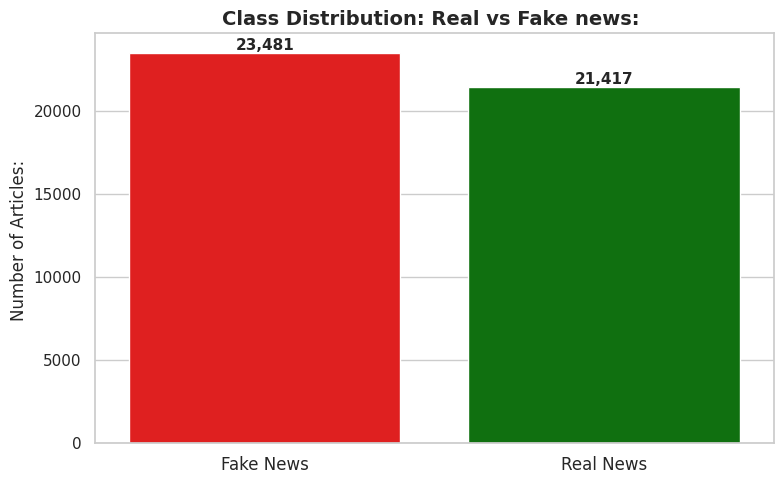

In [14]:
# Checking class balance
class_counts = df['label'].value_counts()
class_percentages = df['label'].value_counts(normalize=True) * 100

print("Class Distribution: ")
print(f"Real News(1) : {class_counts[1]} articles ({class_percentages[1]:.2f}%)")
print(f"Fake News(0) : {class_counts[0]} articles ({class_percentages[0]:.2f}%)")


#visualize
plt.figure(figsize=(8,5))
ax = sns.countplot(x='label', data=df, palette=['red', 'green'])
plt.xticks(ticks=[0,1], labels=['Fake News', 'Real News'], fontsize=12)
plt.title('Class Distribution: Real vs Fake news: ', fontsize=14, fontweight='bold' )
plt.xlabel('')
plt.ylabel('Number of Articles: ', fontsize=12)

# Adding count lables on top of each bar
for i, count in enumerate([class_counts[0], class_counts[1]]):
  ax.text(i, count+200, f'{count:,}', ha='center', fontweight='bold', fontsize=11)


plt.tight_layout()
plt.show()

## 4. Data Quality Checks

Before any preprocessing, we need to check:
- **Missing values** — empty cells will crash our model
- **Duplicates** — repeated articles bias the model
- **Empty texts** — articles with empty `text` field are useless

A common ML failure: training on dirty data and reporting fake high accuracy.

In [18]:
from os import dup
# Check for missing values
print("Missing values per column: ")
print(df.isnull().sum())


# Check for duplicates
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates}")

# Check for empty text fields (text exists but is just whitespace)
empty_texts = (df['text'].str.strip() == '').sum()
print(f"Number of empty text fields: {empty_texts}")


# Drop duplicates if any
if duplicates > 0:
  df = df.drop_duplicates().reset_index(drop=True)
  print(f"\n Removed {duplicates} duplicate rows")

# Drop empty texts if any
if empty_texts > 0:
  df = df[df['text'].str.strip() != ''].reset_index(drop=True)


print(f"\nFinal dataset shape: {df.shape}")

Missing values per column: 
title      0
text       0
subject    0
date       0
label      0
dtype: int64

Number of duplicate rows: 0
Number of empty text fields: 0

Final dataset shape: (44058, 5)


## 5. Text Length Analysis

Here's an interesting question: **Do real and fake news articles differ in length?**

Often, fake news is shorter (clickbait), and real news is longer (detailed reporting). Let's verify this hypothesis with data.

Text length Statistics by class: 

      text_length                                                             \
            count         mean          std    min      25%     50%      75%   
label                                                                          
0         22848.0  2617.773241  2531.650609    5.0  1517.75  2200.0  3059.00   
1         21210.0  2378.154408  1684.428140  152.0   904.00  2216.0  3226.75   

               word_count                                                     \
           max      count        mean         std   min    25%    50%    75%   
label                                                                          
0      51794.0    22848.0  434.893951  407.823671   1.0  254.0  369.0  511.0   
1      29781.0    21210.0  384.775625  273.898818  22.0  147.0  359.0  523.0   

               
          max  
label          
0      8135.0  
1      5172.0  


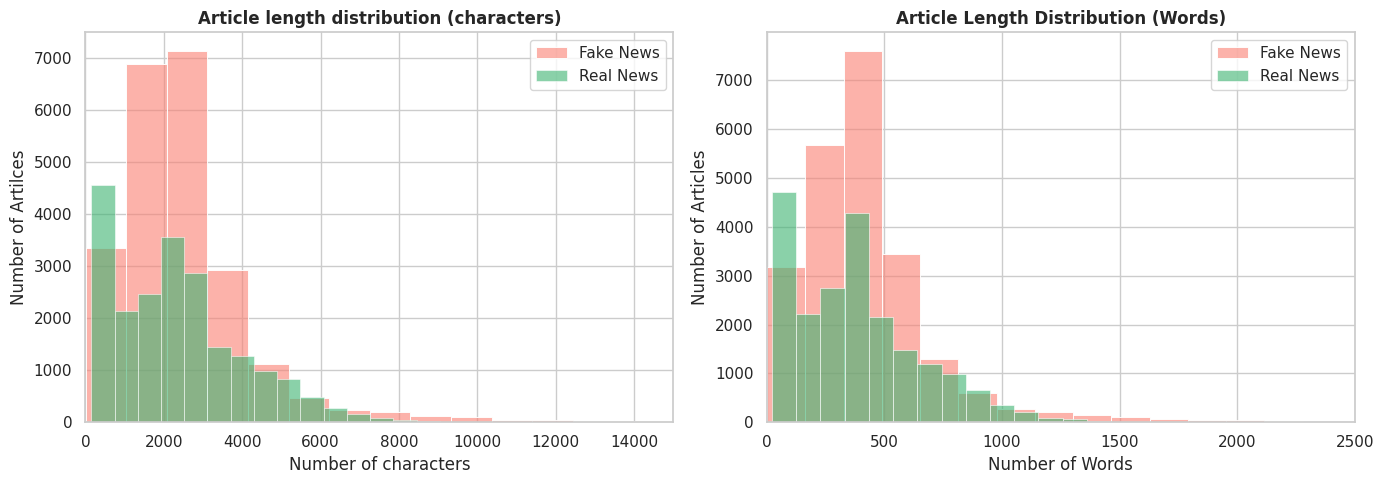


 Key Insight: 
Average real news word count: 385 words
Average fake news word count: 435 words
Difference: 50 words


In [24]:
# Calculate the text length(number of characters) for each articles
df['text_length'] = df['text'].apply(len)

# Calculate the word count too
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

# Show statistics by class
print("Text length Statistics by class: \n")
lenght_stats = df.groupby('label')[['text_length', 'word_count']].describe()
print(lenght_stats)

# Visualize the distribution
fig, axes = plt.subplots(1,2, figsize=(14,5))

# Plot 1: Character length distribution
sns.histplot(data=df[df['label']==0], x='text_length', bins=50, alpha=0.6,
             color ='salmon', label='Fake News', ax=axes[0])
sns.histplot(data=df[df['label']==1], x='text_length', bins=50, alpha=0.6,
             color = 'mediumseagreen', label='Real News', ax=axes[0])

axes[0].set_xlim(0,15000)
axes[0].set_title('Article length distribution (characters)', fontweight='bold')
axes[0].set_xlabel('Number of characters')
axes[0].set_ylabel('Number of Artilces')
axes[0].legend()
# Plot 2: Word count distribution
sns.histplot(data=df[df['label']==0], x='word_count', bins=50, alpha=0.6,
             color='salmon', label='Fake News', ax=axes[1])
sns.histplot(data=df[df['label']==1], x='word_count', bins=50, alpha=0.6,
             color='mediumseagreen', label='Real News', ax=axes[1])
axes[1].set_xlim(0, 2500)
axes[1].set_title('Article Length Distribution (Words)', fontweight='bold')
axes[1].set_xlabel('Number of Words')
axes[1].set_ylabel('Number of Articles')
axes[1].legend()

plt.tight_layout()
plt.show()


# Print key insight
avg_real = df[df['label']==1]['word_count'].mean()
avg_fake = df[df['label']==0]['word_count'].mean()
print(f"\n Key Insight: ")
print(f"Average real news word count: {avg_real:.0f} words")
print(f"Average fake news word count: {avg_fake:.0f} words")
print(f"Difference: {abs(avg_real - avg_fake):.0f} words")

In [25]:
!pip install wordcloud

## 6. Word Cloud Analysis

A picture is worth 1000 words. Word clouds let us instantly see which words are MOST common in real vs fake news.

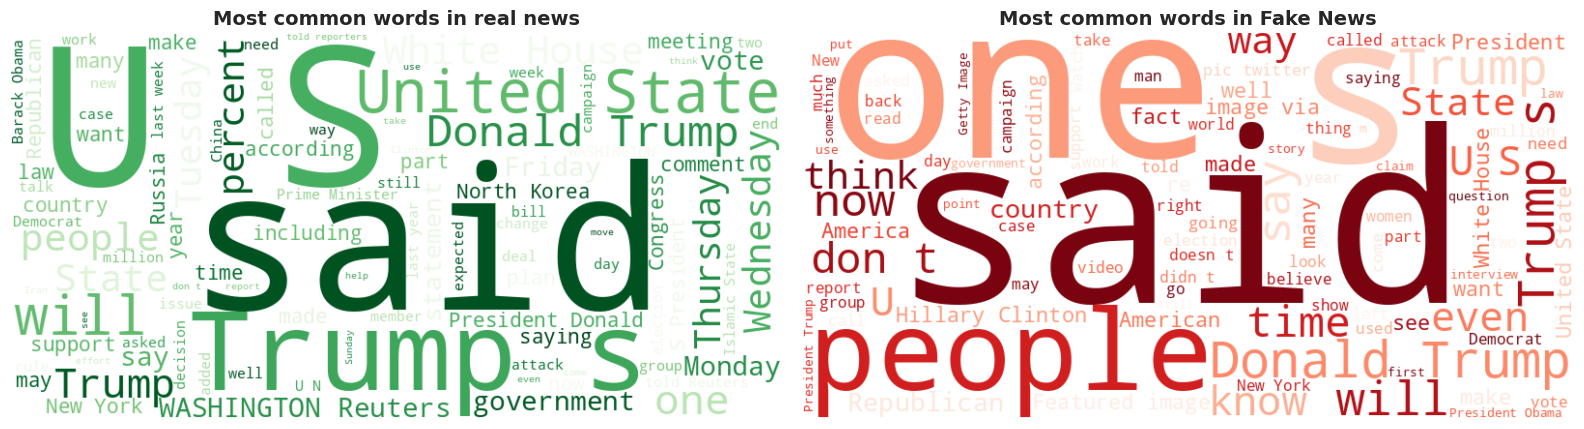

Notice the difference in vocabulary between real and fake news


In [28]:
from wordcloud import WordCloud

real_text = ' '.join(df[df['label'] == 1]['text'].astype(str))
fake_text = ' '.join(df[df['label'] == 0]['text'].astype(str))

# Creating word cloud
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

#Real news word cloud
word_cloud_real = WordCloud(width=800, height=400, background_color='white',
                            colormap='Greens', max_words=100,
                            stopwords=None).generate(real_text)
axes[0].imshow(word_cloud_real, interpolation='bilinear')
axes[0].set_title('Most common words in real news', fontsize=14, fontweight='bold')
axes[0].axis('off')

# Fake news word cloud
word_cloud_fake = WordCloud(width=800, height=400, background_color='white',
                            colormap='Reds', max_words=100,
                            stopwords=None).generate(fake_text)
axes[1].imshow(word_cloud_fake, interpolation='bilinear')
axes[1].set_title('Most common words in Fake News', fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print("Notice the difference in vocabulary between real and fake news")

## 7. Text Preprocessing

Raw text is messy. Before feeding it to our model, we need to clean it:

1. **Lowercase everything** — "Trump" and "trump" should be treated the same
2. **Remove URLs** — links don't help classify
3. **Remove HTML tags** — leftover code junk
4. **Remove punctuation** — `.,!?` adds noise
5. **Remove numbers** — "Trump in 2016" → "Trump in" (numbers usually noise)
6. **Remove extra whitespace** — multiple spaces → single space


In [29]:
def clean_text(text):
  """
  Clean a single text string by applying multiple preprocessing steps.

  Args:
      text(str): Raw text input
  Returns:
      str: Cleaned text
  """

  # convert to lowercase
  text = text.lower()

  # Remove URLS
  text = re.sub(r'http\S+|www\S+|https\S+', '', text)

  # Remove HTML tags
  text = re.sub(r'<.*?>', '', text)

  # Remove punctuations
  text = text.translate(str.maketrans('', '', string.punctuation))

  # Remove numbers
  text = re.sub(r'\d+', '', text)

  # Remove extra whitespace (multiple spaces, tabs, newlines - single space)
  text = re.sub(r'\s+', ' ', text).strip()

  return text


# Test on sample first to make sure it works
sample_text = df['text'].iloc[0]
print("Before Cleaning:")
print(sample_text[:300])
print('\n')
print("After cleaning: ")
print(clean_text(sample_text)[:300])

Before Cleaning:
Donald Trump s White House is in chaos, and they are trying to cover it up. Their Russia problems are mounting by the hour, and they refuse to acknowledge that there are problems surrounding all of this. To them, it s  fake news,  or a  hoax.  However, the facts bear things out differently, and it s


After cleaning: 
donald trump s white house is in chaos and they are trying to cover it up their russia problems are mounting by the hour and they refuse to acknowledge that there are problems surrounding all of this to them it s fake news or a hoax however the facts bear things out differently and it seems that the


### Apply Cleaning to All Articles

Now we apply our `clean_text()` function to every article in the dataset.

We'll use pandas `.apply()` which runs the function on every row.

In [30]:
# Apply the cleaning function to all articles
print("Cleaning all articles: ")

df['cleaned_text'] = df['text'].apply(clean_text)

print("Cleaning complete")
print("\nDataset shape: {df.shape}")
print("\nComparison ")
print("\nOrginal text (first 200 chars):")
print(df['text'].iloc[0][:200])
print("\Cleaned text (first 200 chars)")
print(df['cleaned_text'].iloc[0][:200])



Cleaning all articles: 
Cleaning complete

Dataset shape: {df.shape}

Comparison 

Orginal text (first 200 chars):
Donald Trump s White House is in chaos, and they are trying to cover it up. Their Russia problems are mounting by the hour, and they refuse to acknowledge that there are problems surrounding all of th
\Cleaned text (first 200 chars)
donald trump s white house is in chaos and they are trying to cover it up their russia problems are mounting by the hour and they refuse to acknowledge that there are problems surrounding all of this 


##  8. Train/Test Split

Time to split our data:
- **80% for training** — the model learns patterns from this
- **20% for testing** — we evaluate on data the model has never seen

We use `stratify=y` to ensure the train/test sets have the same class balance as the original data (~52% fake, 48% real).

In [34]:
# Define features (X) and labels(y)
X = df['cleaned_text']
y = df['label']

# Split into train adn test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)


print(f"Training set size: {X_train.shape[0]} articles")
print(f"Testing set size: {X_test.shape[0]} articlees")
print(f"\nClass Distributionn in TRAIN: ")
print(y_train.value_counts(normalize=True).round(3))
print(f"\nClass Distribution in TEST: ")
print(y_test.value_counts(normalize=True).round(3))

Training set size: 35246 articles
Testing set size: 8812 articlees

Class Distributionn in TRAIN: 
label
0    0.519
1    0.481
Name: proportion, dtype: float64

Class Distribution in TEST: 
label
0    0.519
1    0.481
Name: proportion, dtype: float64


## 9. Text Vectorization with TF-IDF

We need to convert text into numbers. We could use `CountVectorizer` (just word counts), but we'll use **TF-IDF** which is smarter.

### What is TF-IDF?

**TF-IDF = Term Frequency × Inverse Document Frequency**

- **TF (Term Frequency)** — how often a word appears in a document
- **IDF (Inverse Document Frequency)** — how RARE a word is across ALL documents

**Why it's better than CountVectorizer:**
- Common words (like "the", "is") get LOW scores → less importance
- Rare, distinctive words get HIGH scores → more importance
- Better discriminative power for classification

This is the **industry standard** for text classification.

In [38]:
# Creating TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words = 'english',
    ngram_range=(1,2),
    min_df = 5,
    max_df = 0.7
)

# Fit the training data only, then transform both
print("Vectorizing text with TF-IDF ")
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"Vectorization Complete")
print(f"\nTraning matrix shape: {X_train_tfidf.shape}")
print(f"\nTesting matrix shape: {X_test_tfidf.shape}")
print(f"\nVocabulary size: {len(tfidf_vectorizer.vocabulary_)}")
print(f"Sample words: {list(tfidf_vectorizer.vocabulary_.keys())[:20]}")

Vectorizing text with TF-IDF 
Vectorization Complete

Traning matrix shape: (35246, 5000)

Testing matrix shape: (8812, 5000)

Vocabulary size: 5000
Sample words: ['donald', 'trump', 'holy', 'like', 'pope', 'example', 'francis', 'asked', 'thursday', 'felt', 'republican', 'took', 'religious', 'leader', 'strength', 'mexico', 'reporter', 'questioned', 'potential', 'president']


## 10. Training Model 1: Multinomial Naive Bayes

We train **Multinomial Naive Bayes** — the gold standard for text classification.

**Why MultinomialNB?**
- Designed specifically for count/frequency data (perfect for TF-IDF)
- Fast training (seconds, not hours)
- Works well even with thousands of features
- Provides probability scores via `predict_proba`

The training process: the model calculates P(word | class) for every word in our 5,000-word vocabulary, then uses Bayes' Theorem to make predictions.

In [39]:
# Create the model
print("Training MultinomialNB...")
mnb_model = MultinomialNB()

# Train on the TF-IDF vectorized training data
mnb_model.fit(X_train_tfidf, y_train)

print("MultinomialNB training complete!")

# Make predictions on the test set
y_pred_mnb = mnb_model.predict(X_test_tfidf)

# Calculate accuracy
mnb_accuracy = accuracy_score(y_test, y_pred_mnb)

print(f"\nMultinomialNB Accuracy: {mnb_accuracy:.4f} ({mnb_accuracy*100:.2f}%)")

Training MultinomialNB...
MultinomialNB training complete!

MultinomialNB Accuracy: 0.9375 (93.75%)


## 📊 11. Detailed Evaluation of MultinomialNB

Accuracy alone isn't enough. We need:
- **Confusion Matrix** — see WHERE the model fails
- **Classification Report** — precision, recall, F1 per class
- **Visualization** — recruiter-friendly heatmap

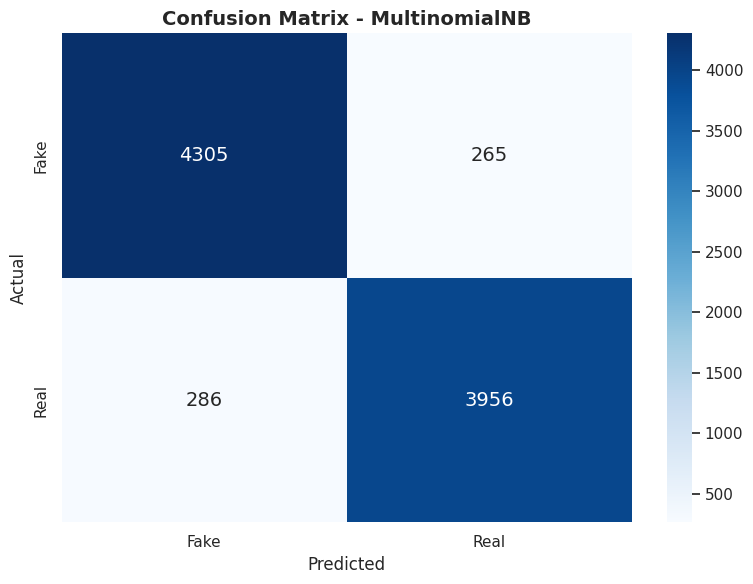

Classification Report - MultinomialNB:

              precision    recall  f1-score   support

   Fake News       0.94      0.94      0.94      4570
   Real News       0.94      0.93      0.93      4242

    accuracy                           0.94      8812
   macro avg       0.94      0.94      0.94      8812
weighted avg       0.94      0.94      0.94      8812


Key Metrics:
   Accuracy:  0.9375
   Precision: 0.9372
   Recall:    0.9326
   F1 Score:  0.9349


In [40]:

# Confusion Matrix
cm_mnb = confusion_matrix(y_test, y_pred_mnb)

# Visualize as heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm_mnb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'Real'],
            yticklabels=['Fake', 'Real'],
            annot_kws={'size': 14})
plt.title('Confusion Matrix - MultinomialNB', fontsize=14, fontweight='bold')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.show()

# Classification Report
print("Classification Report - MultinomialNB:\n")
print(classification_report(y_test, y_pred_mnb,
                            target_names=['Fake News', 'Real News']))

# Extract specific metrics for later comparison
from sklearn.metrics import precision_score, recall_score, f1_score

mnb_precision = precision_score(y_test, y_pred_mnb)
mnb_recall = recall_score(y_test, y_pred_mnb)
mnb_f1 = f1_score(y_test, y_pred_mnb)

print(f"\nKey Metrics:")
print(f"   Accuracy:  {mnb_accuracy:.4f}")
print(f"   Precision: {mnb_precision:.4f}")
print(f"   Recall:    {mnb_recall:.4f}")
print(f"   F1 Score:  {mnb_f1:.4f}")

## 12. Training Model 2: Bernoulli Naive Bayes

Now let's train **Bernoulli Naive Bayes** for comparison.

### Why train two models?

- **Shows engineering rigor** — recruiters love when you compare alternatives instead of picking one blindly
- **Different assumptions** — MultinomialNB uses TF-IDF scores; BernoulliNB cares about word presence/absence (binary)
- **Empirical decision** — let the data tell us which is better, not our guess

### How BernoulliNB differs:

| Aspect | MultinomialNB | BernoulliNB |
|--------|---------------|-------------|
| **Treats features as** | Counts/frequencies | Binary (0 or 1) |
| **Question asked** | "How OFTEN does word X appear?" | "DOES word X appear at all?" |
| **Best for** | Long documents | Short texts, presence-based features |

We'll use the same TF-IDF data — BernoulliNB will internally treat anything > 0 as "1".

Training BernoulliNB...
BernoulliNB training complete!

BernoulliNB Metrics:
   Accuracy:  0.9682 (96.82%)
   Precision: 0.9631
   Recall:    0.9712
   F1 Score:  0.9671


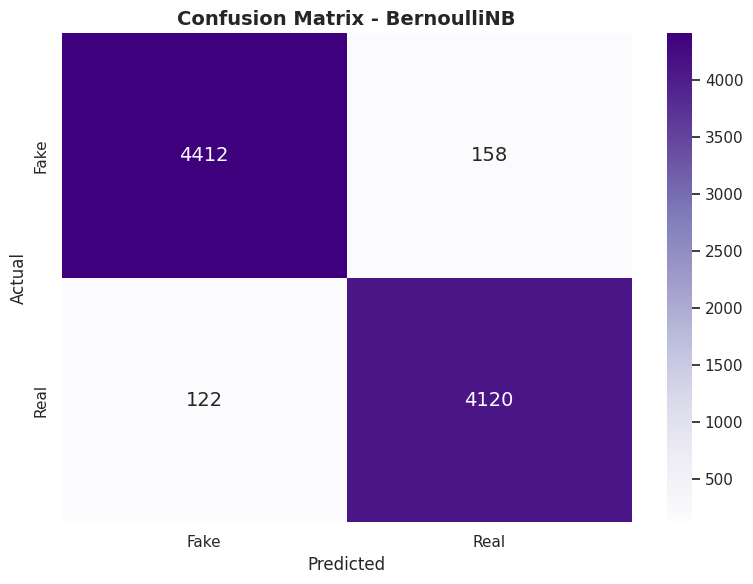


Classification Report - BernoulliNB:

              precision    recall  f1-score   support

   Fake News       0.97      0.97      0.97      4570
   Real News       0.96      0.97      0.97      4242

    accuracy                           0.97      8812
   macro avg       0.97      0.97      0.97      8812
weighted avg       0.97      0.97      0.97      8812



In [41]:
# Create the model
print("Training BernoulliNB...")
bnb_model = BernoulliNB()

# Train on the same TF-IDF data
bnb_model.fit(X_train_tfidf, y_train)

print("BernoulliNB training complete!")

# Make predictions
y_pred_bnb = bnb_model.predict(X_test_tfidf)

# Calculate metrics
bnb_accuracy = accuracy_score(y_test, y_pred_bnb)
bnb_precision = precision_score(y_test, y_pred_bnb)
bnb_recall = recall_score(y_test, y_pred_bnb)
bnb_f1 = f1_score(y_test, y_pred_bnb)

print(f"\nBernoulliNB Metrics:")
print(f"   Accuracy:  {bnb_accuracy:.4f} ({bnb_accuracy*100:.2f}%)")
print(f"   Precision: {bnb_precision:.4f}")
print(f"   Recall:    {bnb_recall:.4f}")
print(f"   F1 Score:  {bnb_f1:.4f}")

# Confusion matrix
cm_bnb = confusion_matrix(y_test, y_pred_bnb)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_bnb, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Fake', 'Real'],
            yticklabels=['Fake', 'Real'],
            annot_kws={'size': 14})
plt.title('Confusion Matrix - BernoulliNB', fontsize=14, fontweight='bold')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.show()

# Classification Report
print("\nClassification Report - BernoulliNB:\n")
print(classification_report(y_test, y_pred_bnb,
                            target_names=['Fake News', 'Real News']))

## 13. Model Comparison: MultinomialNB vs BernoulliNB

Let's compare both models head-to-head with a professional visualization. This is the kind of analysis that separates a "good project" from a "great project" in the eyes of recruiters.

Model Comparison Table:

   Metric  MultinomialNB  BernoulliNB
 Accuracy       0.937472     0.968225
Precision       0.937219     0.963067
   Recall       0.932579     0.971240
 F1 Score       0.934893     0.967136


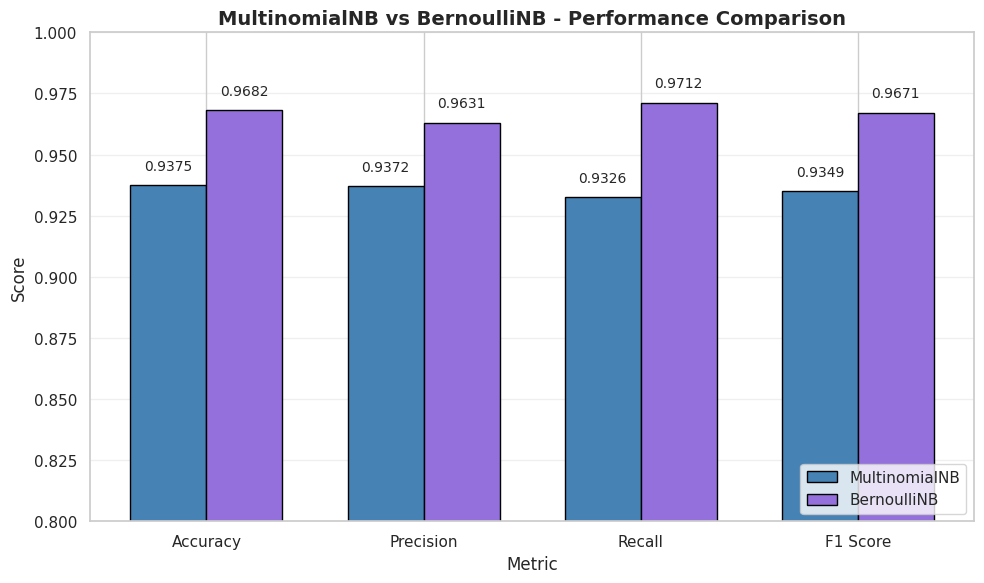


WINNER: BernoulliNB (F1 Score: 0.9671)

Decision: We'll use BernoulliNB as our final model since it has the best F1 score,
   which balances precision and recall — important for a binary classifier
   where both false positives and false negatives matter.


In [42]:

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'MultinomialNB': [mnb_accuracy, mnb_precision, mnb_recall, mnb_f1],
    'BernoulliNB': [bnb_accuracy, bnb_precision, bnb_recall, bnb_f1]
})

print("Model Comparison Table:\n")
print(comparison_df.to_string(index=False))

# Visualize as grouped bar chart
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(comparison_df['Metric']))
width = 0.35

bars1 = ax.bar(x - width/2, comparison_df['MultinomialNB'], width,
               label='MultinomialNB', color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, comparison_df['BernoulliNB'], width,
               label='BernoulliNB', color='mediumpurple', edgecolor='black')

# Add value labels on top of bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                f'{height:.4f}', ha='center', va='bottom', fontsize=10)

ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('MultinomialNB vs BernoulliNB - Performance Comparison',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Metric'])
ax.legend(loc='lower right', fontsize=11)
ax.set_ylim(0.8, 1.0)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Determine the winner
if mnb_f1 > bnb_f1:
    winner = "MultinomialNB"
    winner_f1 = mnb_f1
else:
    winner = "BernoulliNB"
    winner_f1 = bnb_f1

print(f"\nWINNER: {winner} (F1 Score: {winner_f1:.4f})")
print(f"\nDecision: We'll use {winner} as our final model since it has the best F1 score,")
print(f"   which balances precision and recall — important for a binary classifier")
print(f"   where both false positives and false negatives matter.")

## 14. Real-World Testing: Custom News Articles

Time to put the model to the test on REAL news articles. This is where we see if our model actually learned to detect fake news, or just memorized patterns from the training data.

We'll build a reusable function that:
1. Takes any news article as input
2. Cleans it (same preprocessing as training)
3. Vectorizes it (using the SAME vectorizer)
4. Predicts: Real or Fake
5. Shows confidence scores

In [44]:

def predict_news(article_text, model=mnb_model, vectorizer=tfidf_vectorizer):
    """
    Predict whether a news article is real or fake.

    Args:
        article_text (str): The news article text
        model: Trained classifier (default: MultinomialNB)
        vectorizer: Fitted TF-IDF vectorizer

    Returns:
        dict: Prediction result with label and confidence scores
    """
    # Step 1: Clean the input text (same preprocessing as training!)
    cleaned = clean_text(article_text)

    # Step 2: Vectorize (transform, NOT fit_transform — we use trained vocabulary)
    vectorized = vectorizer.transform([cleaned])

    # Step 3: Predict
    prediction = model.predict(vectorized)[0]
    probabilities = model.predict_proba(vectorized)[0]

    # Step 4: Format result
    label = "REAL" if prediction == 1 else "FAKE"
    confidence = probabilities[prediction] * 100

    result = {
        'prediction': label,
        'confidence': f"{confidence:.2f}%",
        'fake_probability': f"{probabilities[0]*100:.2f}%",
        'real_probability': f"{probabilities[1]*100:.2f}%"
    }

    return result


# Test with sample articles
print("TESTING THE MODEL ON CUSTOM ARTICLES")


# Example 1: Real news style (factual, professional tone)
article_1 = """
WASHINGTON (Reuters) - The Federal Reserve raised interest rates by a quarter
percentage point on Wednesday, citing strong job growth and continued inflationary
pressures. Fed Chair Jerome Powell said the central bank remains committed to
bringing inflation back to its 2% target through measured policy adjustments.
The decision was unanimous among voting committee members.
"""

# Example 2: Fake news style (emotional, sensational)
article_2 = """
SHOCKING REVELATION: You won't BELIEVE what scientists just discovered! The
government has been HIDING this incredible secret from us for DECADES. Big Pharma
doesn't want you to know about this one weird trick that doctors HATE. Click here
to see the truth they don't want you to see. Share before they DELETE this!!!
"""

# Example 3: Ambiguous (mixed signals)
article_3 = """
A new study published in the Journal of Medical Research has found that drinking
coffee may have unexpected health benefits. Researchers from Stanford University
analyzed data from over 10,000 participants and concluded that moderate coffee
consumption could reduce the risk of certain conditions by up to 30%.
"""

articles = [
    ("Article 1 (Fed Reserve)", article_1),
    ("Article 2 (Clickbait)", article_2),
    ("Article 3 (Coffee Study)", article_3)
]

for name, article in articles:
    print(f"\n{name}")
    print(f"   Preview: {article.strip()[:100]}...")
    result = predict_news(article)
    print(f"\n   Prediction:    {result['prediction']}")
    print(f"   Confidence:   {result['confidence']}")
    print(f"   Fake Prob:    {result['fake_probability']}")
    print(f"   Real Prob:    {result['real_probability']}")


TESTING THE MODEL ON CUSTOM ARTICLES

Article 1 (Fed Reserve)
   Preview: WASHINGTON (Reuters) - The Federal Reserve raised interest rates by a quarter
percentage point on We...

   Prediction:    REAL
   Confidence:   97.25%
   Fake Prob:    2.75%
   Real Prob:    97.25%

Article 2 (Clickbait)
   Preview: SHOCKING REVELATION: You won't BELIEVE what scientists just discovered! The
government has been HIDI...

   Prediction:    FAKE
   Confidence:   97.85%
   Fake Prob:    97.85%
   Real Prob:    2.15%

Article 3 (Coffee Study)
   Preview: A new study published in the Journal of Medical Research has found that drinking
coffee may have une...

   Prediction:    REAL
   Confidence:   55.72%
   Fake Prob:    44.28%
   Real Prob:    55.72%


## 15. Save the Model for Deployment

Now we save the trained model and vectorizer to disk. Why?

- **For deployment** — the Streamlit app needs to LOAD the model, not retrain it
- **For sharing** — others can use your model without your training pipeline
- **For production** — train once, predict millions of times

We use Python's `pickle` library — the standard way to save sklearn objects.

In [45]:

import os

# Create a 'models' directory if it doesn't exist
os.makedirs('models', exist_ok=True)

# Save the trained MultinomialNB model
with open('models/nb_classifier.pkl', 'wb') as f:
    pickle.dump(mnb_model, f)

# Save the TF-IDF vectorizer
with open('models/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)

# Verify they were saved
print("Files saved successfully!\n")
print("Files in models/ directory:")
for filename in os.listdir('models'):
    filepath = os.path.join('models', filename)
    size_kb = os.path.getsize(filepath) / 1024
    print(f"   - {filename} ({size_kb:.2f} KB)")

# Test loading them back (sanity check)
print("\nVerifying we can load them back...")
with open('models/nb_classifier.pkl', 'rb') as f:
    loaded_model = pickle.load(f)
with open('models/tfidf_vectorizer.pkl', 'rb') as f:
    loaded_vectorizer = pickle.load(f)

# Test prediction with loaded model
test_text = "Breaking news from Reuters about the economy"
test_cleaned = clean_text(test_text)
test_vec = loaded_vectorizer.transform([test_cleaned])
test_pred = loaded_model.predict(test_vec)[0]
test_proba = loaded_model.predict_proba(test_vec)[0]

print(f"\nLoaded model works correctly!")
print(f"   Test prediction: {'REAL ' if test_pred == 1 else 'FAKE '}")
print(f"   Confidence: {max(test_proba)*100:.2f}%")

Files saved successfully!

Files in models/ directory:
   - tfidf_vectorizer.pkl (184.89 KB)
   - nb_classifier.pkl (156.85 KB)

Verifying we can load them back...

Loaded model works correctly!
   Test prediction: REAL 
   Confidence: 66.63%


In [46]:
# Downloading files

from google.colab import files

# Downloading both pickle files

files.download('models/nb_classifier.pkl')
files.download('models/tfidf_vectorizer.pkl')

print("\nFiles downloaded! Check your Downloads folder.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Files downloaded! Check your Downloads folder.
